# Machine Learning in Computational Biology
## Spring 2026 • Assignment #1
### Epigenetic Age Prediction from DNA Methylation
Maria-Despoina Liassa


## Task 1: Data Loading and Preprocessing

## 1.1 Data splitting

- The dataset (subset of GSE40279 (Hannum et al., 2013) ) contains DNA methylation beta values (ranging from 0 to 1)
    - 0--> unmethylated
    - 1--> methylated
- Each CpG feature (column starting with 'cg') represents the proportion of methylated reads at a specific genomic position

In [27]:
import os
import sys

# 1.Direct to the main root to have access in the folders
sys.path.append(os.path.abspath('../'))
# 2.Import functions from the corresponding file 
from src.functions import create_stratify_bins, data_split
print("The functions are ready for use in the notebook")

The functions are ready for use in the notebook


In [120]:
# Load Libraries
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [29]:
# Load data 
file_path = '../data/development_data.csv'
df = pd.read_csv(file_path)
print(df.head(10))

print("Total number of samples:")
print(len(df))

   sample_id  age             ethnicity sex  cg16867657  cg06639320  \
0  GSM990554   79  Caucasian - European   M    0.672001    0.504461   
1  GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214   
2  GSM990589   78  Caucasian - European   M    0.781318    0.554360   
3  GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584   
4  GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217   
5  GSM990031   64  Caucasian - European   M    0.653695    0.455073   
6  GSM990020   85  Caucasian - European   M    0.806705    0.513332   
7  GSM990322   61    Hispanic - Mexican   F    0.618697    0.510743   
8  GSM989904   89  Caucasian - European   M    0.766805    0.497230   
9  GSM990395   46    Hispanic - Mexican   F    0.603756    0.420318   

   cg24724428  cg07553761  cg22454769  cg06784991  ...  cg17321954  \
0    0.331257    0.327287    0.572867    0.309496  ...    0.174936   
1    0.160708    0.230875    0.464971    0.223665  ...    0.154691   
2    0.3

In [ ]:
# Generate descriptive statistics for all columns including categorical variables
df.describe(include='all')

,sample_id,age,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
count,456,456.000000,456,456,441.000000,444.000000,444.000000,439.000000,445.000000,442.000000,...,443.000000,445.000000,440.000000,438.000000,439.000000,447.000000,444.000000,449.000000,441.000000,442.000000
unique,456,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GSM990554,NaN,Caucasian - European,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,308,232,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,64.451754,NaN,NaN,0.672185,0.474773,0.258354,0.306423,0.595564,0.288657,...,0.178872,0.079003,0.159781,0.315001,0.052955,0.503354,0.748769,0.272942,0.295699,0.328856
std,NaN,14.631964,NaN,NaN,0.077055,0.054078,0.075822,0.068490,0.079845,0.050484,...,0.026149,0.037605,0.030063,0.053531,0.029233,0.039453,0.052084,0.034739,0.028885,0.035468
min,NaN,19.000000,NaN,NaN,0.445097,0.282605,0.067115,0.128342,0.334084,0.177003,...,0.123852,0.009463,0.065345,0.091694,0.008391,0.362170,0.443848,0.180870,0.204703,0.112017
25%,NaN,54.000000,NaN,NaN,0.618232,0.438860,0.204332,0.254861,0.548695,0.254821,...,0.161000,0.054660,0.140273,0.281743,0.032664,0.479161,0.714236,0.247651,0.278145,0.309714
50%,NaN,65.000000,NaN,NaN,0.671475,0.474176,0.254157,0.303910,0.592122,0.283393,...,0.177849,0.070133,0.161703,0.317862,0.045958,0.505584,0.751891,0.272034,0.294440,0.332205
75%,NaN,75.250000,NaN,NaN,0.730840,0.509154,0.303655,0.347685,0.647835,0.311986,...,0.193245,0.096696,0.180514,0.348837,0.067091,0.528347,0.782235,0.296712,0.314815,0.351723


### Initial EDA 

/tmp/ipykernel_64700/2930886394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sex", palette="viridis")


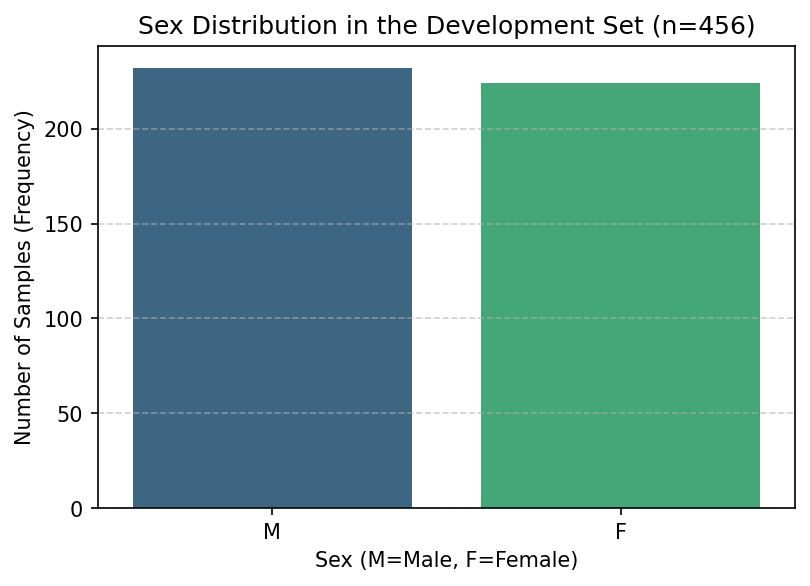

In [ ]:
# 150 dpi quality
plt.figure(figsize=(6, 4), dpi=150) 
sns.countplot(data=df, x="sex", palette="viridis") 

# Title & labels
plt.title("Sex Distribution in the Development Set (n=456)", fontsize=12)
plt.xlabel("Sex (M=Male, F=Female)", fontsize=10)
plt.ylabel("Number of Samples (Frequency)", fontsize=10)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save image in figures
plot_path = '../figures/Sex Distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

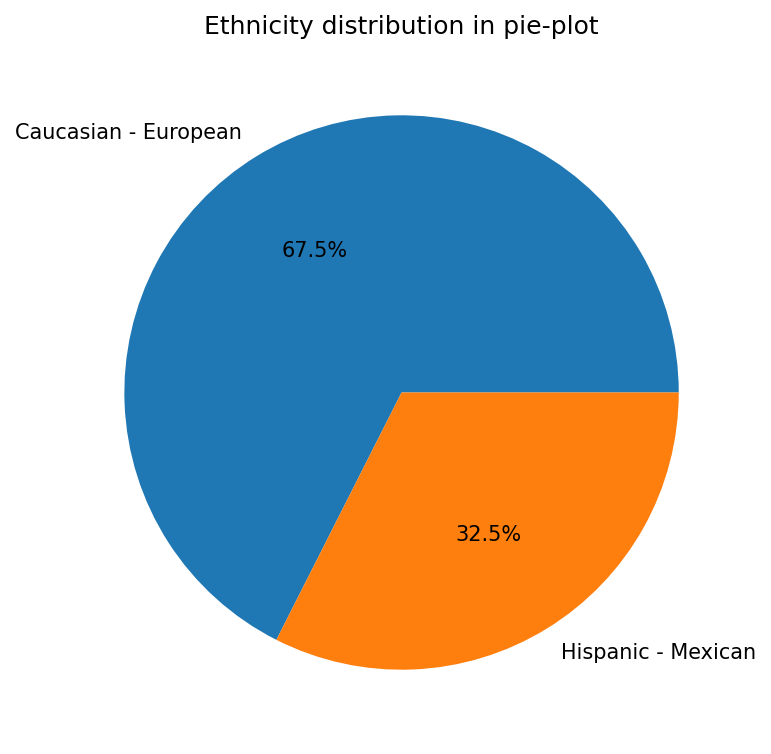

In [ ]:
# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
df["ethnicity"].value_counts(normalize=True).plot.pie(autopct="%.1f%%") 

# Title & labels
plt.title("Ethnicity distribution in pie-plot")

# Save image in figures
plot_path = '../figures/Ethnicity distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

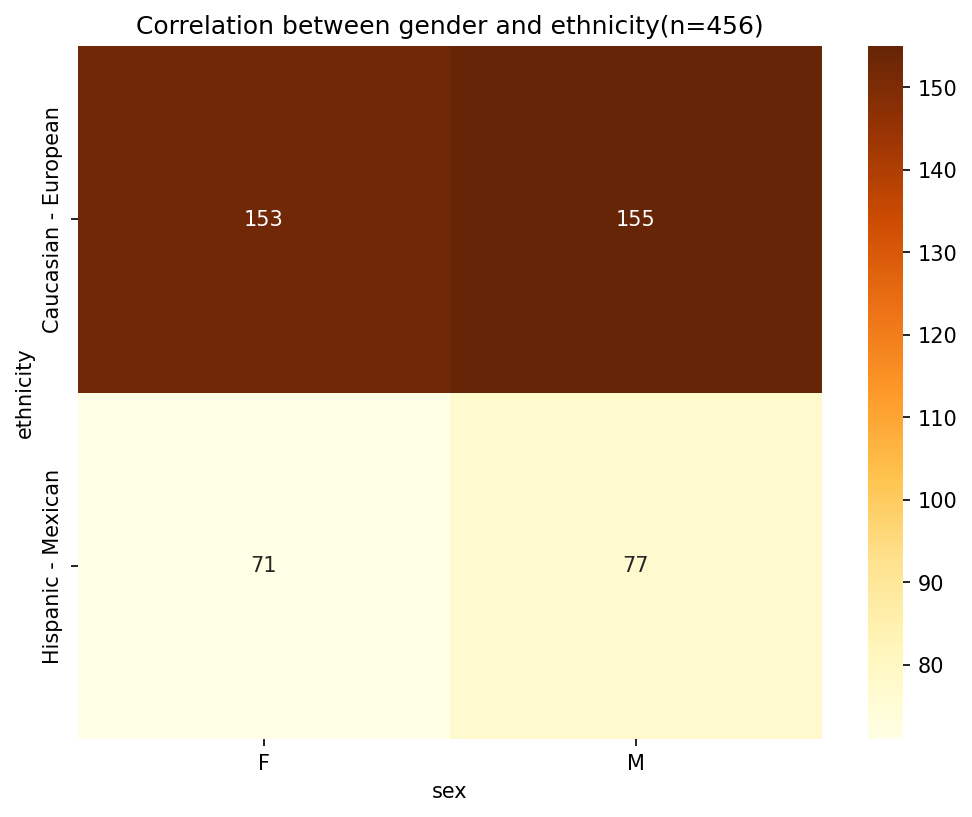

In [ ]:
# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
#sns.heatmap(pd.crosstab(df["ethnicity"], df["sex"]), annot=True, fmt="d") 
sns.heatmap(pd.crosstab(df["ethnicity"], df["sex"]), annot=True, fmt="d", cmap="YlOrBr")
# Title & labels
plt.title("Correlation between gender and ethnicity(n=456)", fontsize=12)

# Save image in figures
plot_path = '../figures/Correlation gender-ethnicity.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

count    456.000000
mean      64.451754
std       14.631964
min       19.000000
25%       54.000000
50%       65.000000
75%       75.250000
max      101.000000
Name: age, dtype: float64


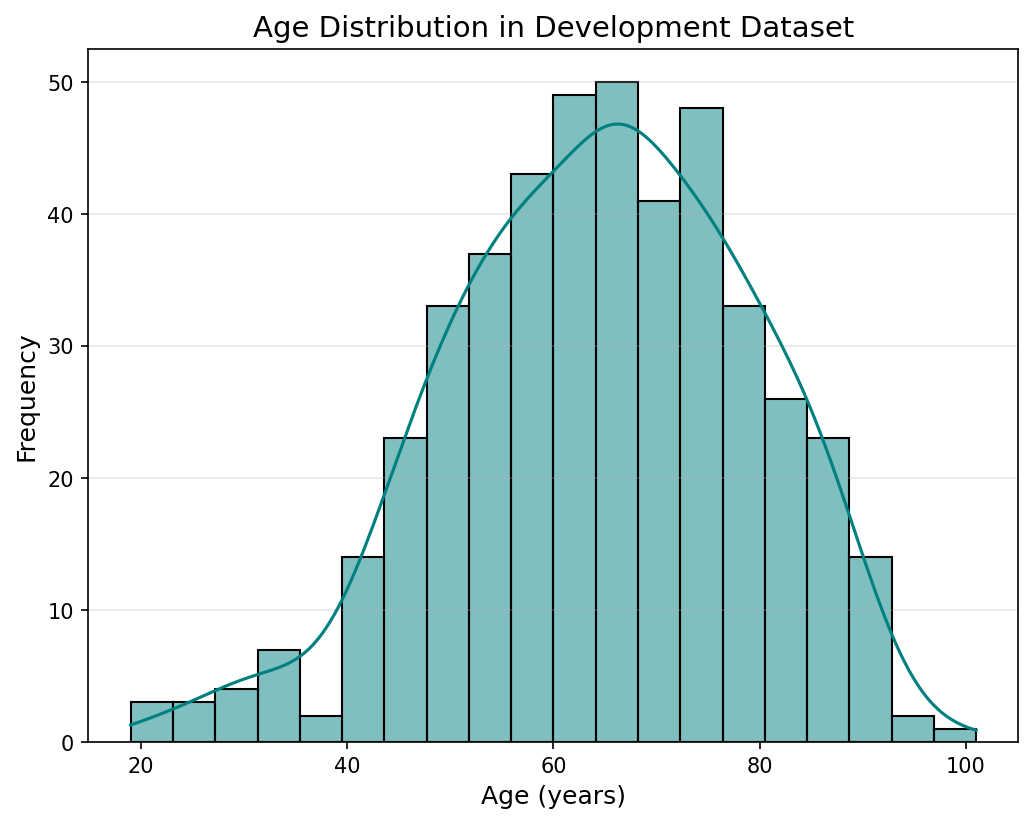

In [ ]:
# Age Statistics
print(df['age'].describe())

# Age Distribution 
# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
sns.histplot(df['age'], bins=20, kde=True, color='teal')

# Title & labels
plt.title('Age Distribution in Development Dataset', fontsize=14)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Grid
plt.grid(axis='y', alpha=0.3)

# Save image in figures
plot_path = '../figures/Age Distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

Before splitting the data, we need to take a look at the distribution of the class. We observe that dataset forms a Normal Distribution with a right skew. This means that the majority of the data are repserented by elderly people, there are less data for people between 20-45 years old. However there are data for all age groups. This imbalance in the classes is a strong indication to use stratified splitting

In [76]:
# View number of samples in the dataset 
print("Total number of samples:")
print(len(df))
# View the unique values in Ethnicity 
print("\nUnique values in Ethnicity:")
print(df['ethnicity'].value_counts())
# View the unique values in Sex
print("\nUnique values in Sex:")
print(df['sex'].value_counts())

Total number of samples:
456

Unique values in Ethnicity:
ethnicity
Caucasian - European    308
Hispanic - Mexican      148
Name: count, dtype: int64

Unique values in Sex:
sex
M    232
F    224
Name: count, dtype: int64


### EDA for decision making on the approach for data pre-processing

- Before the preprocessing we need to investigate the values of the data per column and the nature of missing values 
- Since the missing values are random, we need to ckeck if they are numeric or/and categorical, to deal with them appropriately

In [108]:
# Check for missing values in numerical columns
# 1.Total missing values per coolumn
missing_counts = df.isnull().sum()

# 2. Filter columns and get those that have at least 1 missing value
missing_only = missing_counts[missing_counts > 0]

# 3. Percentage calculation
missing_percentage = (missing_only / len(df)) * 100

# 4. Print results in a dataframe
missing_info = pd.DataFrame({
    'Missing Values': missing_only,
    'Percentage (%)': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print(f"Number of CgPs with missing values:{(df.isnull().sum() > 0).sum()}")

print("\nColumns with missing values:")
if missing_info.empty:
    print("There is no column with missing values")
else:
    print(missing_info)

# Check for missing values in categorical columns
print("\nCategorical columns:")
for col in ['sex', 'ethnicity','age']:
    print(f"{col}: {df[col].isnull().sum()} missing")

Number of CgPs with missing values:1000

Columns with missing values:
            Missing Values  Percentage (%)
cg26330518              32        7.017544
cg25410668              28        6.140351
cg15903032              25        5.482456
cg01493685              25        5.482456
cg12233363              25        5.482456
...                    ...             ...
cg19804488               4        0.877193
cg25236230               4        0.877193
cg22512670               4        0.877193
cg20469744               4        0.877193
cg16431787               4        0.877193

[1000 rows x 2 columns]

Categorical columns:
sex: 0 missing
ethnicity: 0 missing
age: 0 missing


- Missing values are detected only in the CpG columns varying between 0.8 % to 7% 
- However the impresive is that we have missing values to ALL the CgP columns
- Even if deleteting missing values is an approach, imputing is prefereable
- Need to decide whether the median or mean is the more appropriate approach of missing values replacemnt for this dataset. 
    - Median is a robust measure in an ordered dataset which makes it a preferable candidate if the dataset has strong indications of outliers. This is because median represents a stable point within a distribution
    - Mean  is used more often in normal distributed data, where there is not skewness which implies outliers in the data
- Let's investigate which option is more suitable for this dataset 

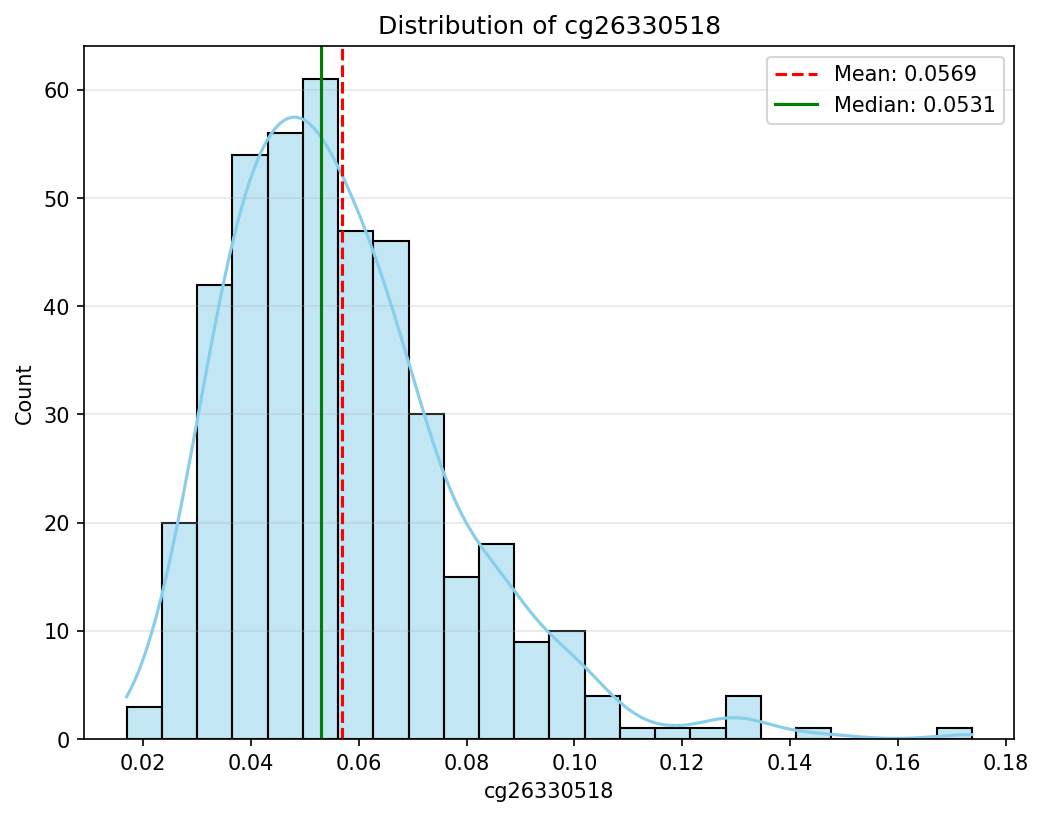

In [ ]:
# Use column cg26330518 which has the higher amount of missing values 
cpg_col = 'cg26330518'

# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
sns.histplot(df[cpg_col].dropna(), kde =True, color='skyblue')

# Calculate Mean & Median
plt.axvline(df[cpg_col].mean(), color='red', linestyle='--', label=f'Mean: {df[cpg_col].mean():.4f}')
plt.axvline(df[cpg_col].median(), color='green', linestyle='-', label=f'Median: {df[cpg_col].median():.4f}')

# Title & labels
plt.title(f'Distribution of {cpg_col}')

# Grid & Legend
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Save image in figures
plot_path = '../figures/cg26330518 Distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")


In [110]:
# Calculate skewness only for CgP columns with missing values
cols_with_missing = missing_info.index
all_skews = df[cols_with_missing].skew()

# Skewness statistics
print("Statistic Skewness for CgP with missing values:")
print(all_skews.describe())

# Number of CgPs with strong skewness (> 1 ή < -1);
high_skew = all_skews[(all_skews > 1) | (all_skews < -1)]
print(f"\nCgPs with strong skewness: {len(high_skew)} out of {len(cols_with_missing)}")

Statistic Skewness for CgP with missing values:
count    1000.000000
mean        0.075248
std         0.960081
min        -5.736891
25%        -0.437509
50%        -0.092593
75%         0.356041
max         7.835384
dtype: float64

CgPs with strong skewness: 171 out of 1000


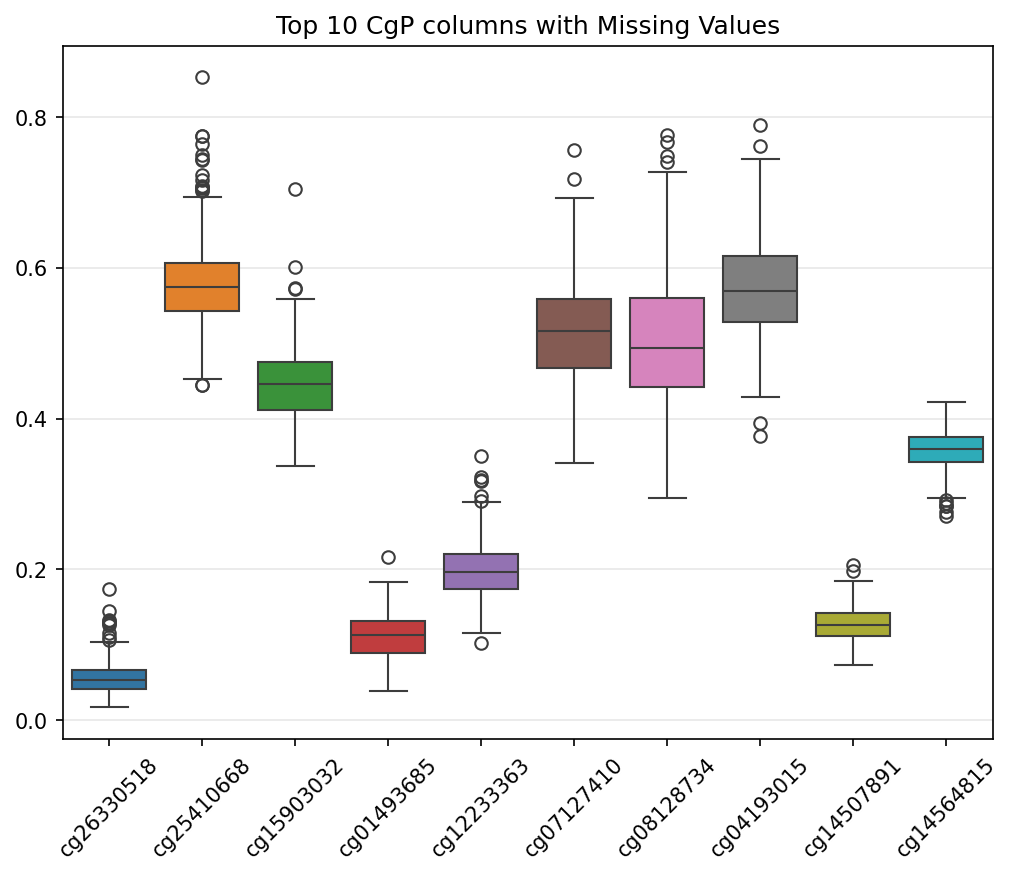

In [ ]:
top_10_missing = missing_info.head(10).index

# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
sns.boxplot(data=df[top_10_missing])

# Title & labels
plt.xticks(rotation=45)
plt.title("Top 10 CgP columns with Missing Values")

# Grid
plt.grid(axis='y', alpha=0.3)

# Save image in figures
plot_path = '../figures/Top CgP columns with Missing Values.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")


- The distribution of values above, pictures that  Median and Mean are almost identical, which initially indicated that using Mean is currently a safe approach and it won't affect downstream Analysis
- However skewness analysis across all 1,000 CpG sites revealed that 17.1% of the features exhibit strong skewness (ranging from -5.7 to 7.8). Whivh is also confirmed by boxplot visualization that reveal the presence of significant outliers in several features. To ensure robustness against these outliers and prevent biased estimations, the Median Imputation strategy was adopted as the most appropriate method for this dataset
- However Median will be calculated by Training set(X_train) only to avoid data leakage. Otherwise if we would applied imputing before splitting or calculating by the whole sataset, values from validation set would impact the calculation  

- CgP columns represent the percentage of methylation on DNA positions and their values are the mean of methylation calculated by the all the cells  on this position 
- Since we deal with beta values (data are striclty between the close interval 0 and 1) ... Normalisation method 

Unique values in Sex: <StringArray>
['M', 'F']
Length: 2, dtype: str
Unique values in Ethnicity: <StringArray>
['Caucasian - European', 'Hispanic - Mexican']
Length: 2, dtype: str


/tmp/ipykernel_64700/171692303.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='age', data=df, ax=ax1, palette="Set2")
/tmp/ipykernel_64700/171692303.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ethnicity', y='age', data=df, ax=ax2,palette="Set2")


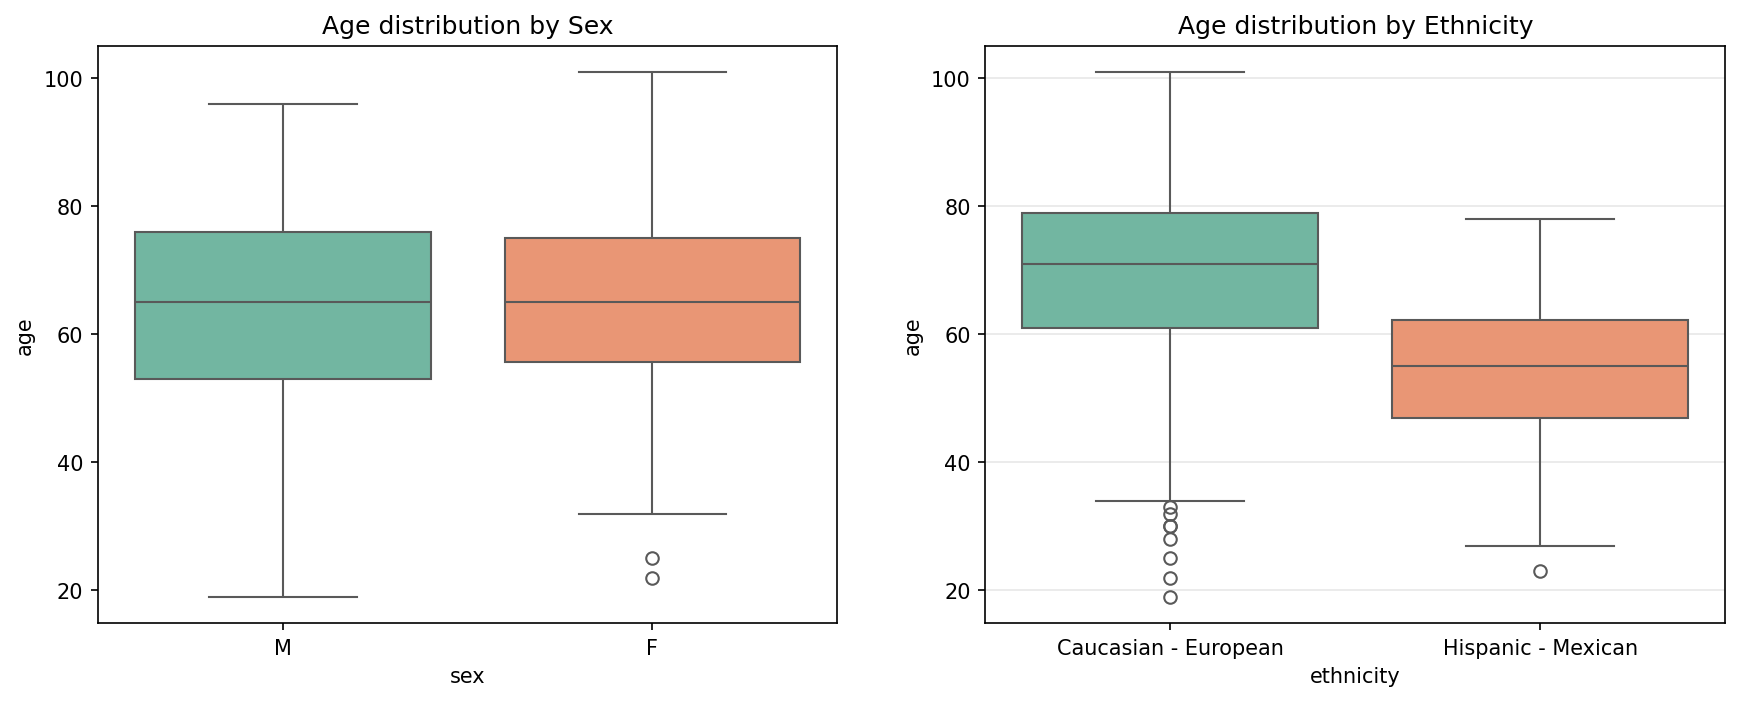

In [ ]:
# Take unique values
print("Unique values in Sex:", df['sex'].unique())
print("Unique values in Ethnicity:", df['ethnicity'].unique())

# Subplots with 150 dpi quality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Title & labels
sns.boxplot(x='sex', y='age', data=df, ax=ax1, palette="Set2")
ax1.set_title('Age distribution by Sex')

sns.boxplot(x='ethnicity', y='age', data=df, ax=ax2,palette="Set2")
ax2.set_title('Age distribution by Ethnicity')

# Grid 
plt.grid(axis='y', alpha=0.3)

# Save figure
plot_path = '../figures/Age-Sex-Ethnicityn.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

- In order to decide which features provide have prediction value, it was necessary to see the correlation between the 'Age-Sex' and 'Age-Ethnicity'
- Observing boxplots above, Sex doesn't have a prediction value in contrast with Ethicity,we could discarge that but we will keep it for the original EDA analysis
-exclude from the training set sample_id (which doesn't provide any biolological significance to the analysis), and of course Age which is our target column 

We take the unique values to see (again) if there are any missing values in those features and to ensure the names of the values in those features

In [113]:
# Transforms a continues variable into bins for stratification
# 1. Create bins by the range of age in this dataset
bins = create_stratify_bins(df['age'], num_bins=4)

# 2. Splitting 
train_df, val_df = data_split(df, stratify_col=bins)

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")
print(f"Split successful with seed 42 and stratified age bins")

Train size: 364, Val size: 92
Split successful with seed 42 and stratified age bins


In [114]:
# View top 10 samples characterized by bins
print("Top 10 bins:")
print(bins[:10])

# View how many samples each bin has 
unique, counts = np.unique(bins, return_counts=True)
print("\nDistribution of samples per bin:")
print(dict(zip(unique, counts)))

Top 10 bins:
[3 2 3 2 2 3 4 3 4 2]

Distribution of samples per bin:
{np.int64(1): np.int64(19), np.int64(2): np.int64(150), np.int64(3): np.int64(221), np.int64(4): np.int64(66)}


We created 4 bins to correlate the age groups : 
- bin 1 stands for young people
- bin 2 stands for middle aged people
- bin 3 stands for elderly people
- bin 4 stands for very elderly people


In [115]:
# Choose the fearures and the label column to separate the data
# Exclude 'age' cause this is the target & sample_id' cause is not useful for prediction
features_to_drop = ['sample_id', 'age']

X_train = train_df.drop(columns=features_to_drop) 
X_val = val_df.drop(columns=features_to_drop)

y_train = train_df['age']
y_val = val_df['age']

# Validate that the splitting is 80-20
print(f"X_train shape: {X_train.shape} (Δείγματα, Χαρακτηριστικά)")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape} (Δείγματα, Χαρακτηριστικά)")
print(f"y_val shape: {y_val.shape}")

X_train shape: (364, 1002) (Δείγματα, Χαρακτηριστικά)
y_train shape: (364,)
X_val shape: (92, 1002) (Δείγματα, Χαρακτηριστικά)
y_val shape: (92,)


In [116]:
print(f"y_val values:\n{y_val.head()}")

y_val values:
91     83
372    57
71     55
397    70
314    63
Name: age, dtype: int64


## 1.2 Preprocessing 

- As prooved the more appropriate approach for imputing this dataset is the 'median'  
- StandardScaler used for scaling the data
- One-Hot-Encoding was chosen to transform categorical data into their numeric form. This method added 4 more columns to the dataset, since only 2 variables appearing under the 'Ethnicity' feature and another 2 under 'Sex' feature. This approach is more suitable for this project, since the shape of the dataframe didn't change significalty by adding only 4 extra columns. This would be a problem if we had more values describing those features. Also, Label Encoding might feels like a satisfying method, since it assigns each category of a categorical variable a unique integer value and is preferable for memory efficiency. This converts the categorical column into a single numerical feature. But that's not the case here, since this method is suitable for ordinal data only, cause it assumes that there is an order between the them

In [42]:
from src.functions import get_preprocessing_pipeline

# 1. Set the columns to be processed
cpg_cols = [col for col in X_train.columns if col.startswith('cg')] # CgP cols
cat_cols = ['sex', 'ethnicity'] # the only categorcal columns needed

# 2. Create preprocessor object
preprocessor = get_preprocessing_pipeline(cpg_cols, cat_cols)

# 3. Fit & Transform on X_train
X_train_final = preprocessor.fit_transform(X_train)

# 4. Transform to Validation Set
# Apply the fitting & transform learned from X_train to X_val
X_val_final = preprocessor.transform(X_val)

# 5. Check results
print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_val_final shape: {X_val_final.shape}")

X_train_final shape: (364, 1002)
X_val_final shape: (92, 1002)


## 1.3 Exploratory analysis

In [43]:
df.head()

,sample_id,age,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
0,GSM990554,79,Caucasian - European,M,0.672001,0.504461,0.331257,0.327287,0.572867,0.309496,...,0.174936,0.094635,0.163394,0.304777,0.093110,0.522947,0.736352,0.262954,0.295386,0.350803
1,GSM990278,46,Hispanic - Mexican,M,0.555411,0.389214,0.160708,0.230875,0.464971,0.223665,...,0.154691,0.043087,0.173311,0.343683,0.029271,0.496056,0.801962,0.291890,0.288421,0.318693
2,GSM990589,78,Caucasian - European,M,0.781318,0.554360,0.337578,0.437668,0.645529,0.309615,...,0.213999,0.089760,0.173368,0.338127,0.066988,0.484525,0.588307,0.276745,0.263589,0.344015
3,GSM990323,46,Hispanic - Mexican,F,0.542491,0.435584,0.228723,0.231709,0.493908,0.245836,...,0.198334,0.121145,0.164312,0.394890,0.044809,0.510717,0.736712,0.287274,0.333076,0.303317
4,GSM990116,59,Hispanic - Mexican,F,0.653190,0.466217,0.208453,0.284740,0.592122,0.239320,...,0.147234,0.035716,0.156062,0.341784,0.024294,NaN,0.828072,0.256653,0.322450,0.370363


In [ ]:
# Need the 2 last columns with the encoded categorical values 
new_feature_names = preprocessor.get_feature_names_out()
metadata_encoded = X_train_final[:, -2:]
# Create a DataFrame for printing
check_encoding = pd.DataFrame(
    metadata_encoded, 
    columns=new_feature_names[-2:]
)

# Print encoded features
print("--- Top 15 encoded Metadata (0/1) ---")
check_encoding[['cat__sex_M', 'cat__ethnicity_Hispanic - Mexican']].head(15)

--- Top 15 encoded Metadata (0/1) ---


,cat__sex_M,cat__ethnicity_Hispanic - Mexican
0,0.0,0.0
1,0.0,0.0
2,1.0,0.0
3,1.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,1.0,0.0
9,0.0,0.0


In [44]:
from src.functions import get_split_stats

import pandas as pd

# Fill a list with the values calculated my the get_split_stats function
stats_list = [
    get_split_stats('Training', train_df),
    get_split_stats('Validation', val_df),
    get_split_stats('Total Development', df)
]

# Create a dataframe to load the values
stats_table = pd.DataFrame(stats_list)

print("--- Task 1: Dataset Statistics Table ---")
display(stats_table)

--- Task 1: Dataset Statistics Table ---


,Split,n (Samples),Age (Mean ± Std),Age Range,Sex Balance (% Male)
0,Training,364,64.34 ± 14.71,19 - 101,51.1%
1,Validation,92,64.88 ± 14.38,27 - 92,50.0%
2,Total Development,456,64.45 ± 14.63,19 - 101,50.9%


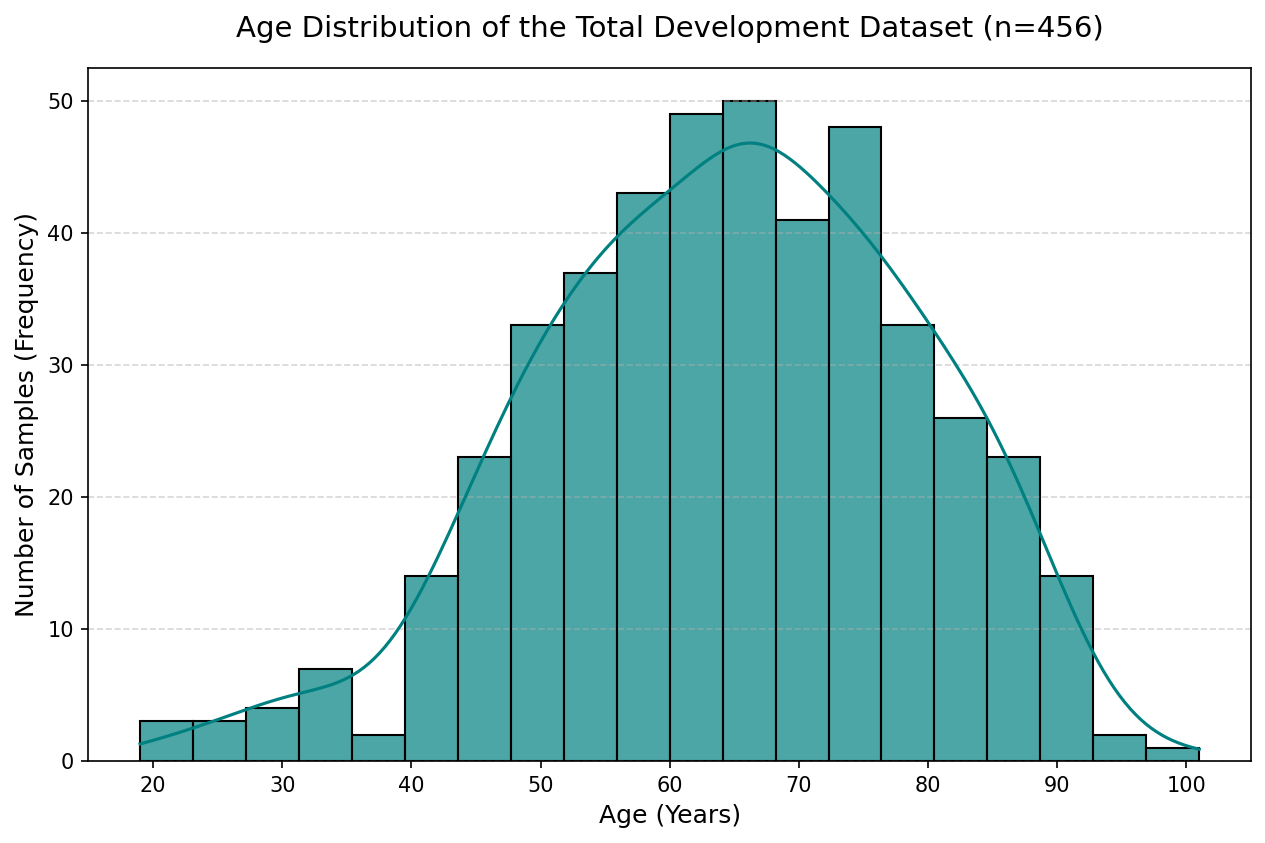

Follow this path to locate the figure: ../figures/age_distribution_final.png


In [129]:
# 150 dpi quality
plt.rcParams['figure.dpi'] = 150
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, color='teal', bins=20, edgecolor='black', alpha=0.7)

# Title & labels 
plt.title('Age Distribution of the Total Development Dataset (n=456)', fontsize=14, pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Samples (Frequency)', fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(15, 105)

# Save image in figures
plot_path = '../figures/age_distribution_final.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

In [46]:
print("Shape:", df.shape)             # How many rows and columns (dataset size).
print("\nData Types:\n", df.dtypes) 

Shape: (456, 1004)

Data Types:
 sample_id         str
age             int64
ethnicity         str
sex               str
cg16867657    float64
               ...   
cg12179661    float64
cg16780603    float64
cg00588614    float64
cg13039082    float64
cg16640358    float64
Length: 1004, dtype: object


In [132]:
print(f"Train shape: {X_train_final.shape}")
print(f"Val shape : {X_val_final.shape}")

Train shape: (364, 1002)
Val shape : (92, 1002)


In [133]:
# Έλεγχος αν υπάρχουν NaN στον τελικό πίνακα
nan_count = np.isnan(X_train_final).sum()
print(f"Number of missing values: {nan_count}")

Number of missing values: 0


In [134]:
# 1. Matrix με ΜΟΝΟ τα Metadata (Sex, Ethnicity)
# Είναι οι δύο τελευταίες στήλες του επεξεργασμένου πίνακα
X_train_meta = X_train_final[:, -2:]
X_val_meta = X_val_final[:, -2:]

# 2. Matrix με ΜΟΝΟ τα CpG Features (DNA Methylation)
# Είναι όλες οι στήλες ΕΚΤΟΣ από τις δύο τελευταίες
X_train_cpg = X_train_final[:, :-2]
X_val_cpg = X_val_final[:, :-2]

# 3. Matrix με ΟΛΑ τα Features (CpGs + Metadata)
# Αυτός είναι ο X_train_final που ήδη έχουμε
X_train_all = X_train_final
X_val_all = X_val_final

print("--- Feature Matrices Created ---")
print(f"Metadata Matrix shape: {X_train_meta.shape}")
print(f"CpG Matrix shape:      {X_train_cpg.shape}")
print(f"Combined Matrix shape: {X_train_all.shape}")

--- Feature Matrices Created ---
Metadata Matrix shape: (364, 2)
CpG Matrix shape:      (364, 1000)
Combined Matrix shape: (364, 1002)
